# Direction H: Domain / functional annotation feature augmentation for Salmonella AMR

> Nếu gen phụ là nguồn tín hiệu chính, liệu việc gom các gen thành nhóm chức năng/domain-like có giúp tăng hiệu năng hoặc giúp giải thích mô hình tốt hơn không?


1. Clone GitHub bài báo 2025.
2. Đọc nhãn kháng/nhạy cho 5 thuốc.
3. Đọc ma trận gen phụ đầy đủ.
4. Cố gắng đọc bảng chú giải Roary nếu có.
5. Chọn 200 gen phụ chỉ trên tập huấn luyện.
6. Tạo đặc trưng nhóm chức năng/domain-like từ annotation keyword.
7. So sánh:
   - gen phụ 200 đặc trưng;
   - nhóm chức năng/domain-like only;
   - gen phụ 200 + nhóm chức năng/domain-like.
8. Có cell **HMMER-ready**: nếu có protein FASTA và HMM database thì chạy hmmscan.


In [1]:
# =========================
# 0. Setup
# =========================
from pathlib import Path
import os, re, json, shutil, subprocess, textwrap, warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path('/content/salmonella_direction_H_domain')
REPO_URL = 'https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git'
REPO_DIR = BASE_DIR / 'Antimicrobial-resistance-prediction-in-Salmonella'
EXTRACT_DIR = BASE_DIR / 'extracted'
OUT_DIR = BASE_DIR / 'outputs'
for d in [BASE_DIR, EXTRACT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('OUT_DIR:', OUT_DIR)


BASE_DIR: /content/salmonella_direction_H_domain
OUT_DIR: /content/salmonella_direction_H_domain/outputs


In [2]:
# =========================
# 1. Clone repo and install minimal tools
# =========================
if not REPO_DIR.exists():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print('Repo đã tồn tại:', REPO_DIR)

# unrar để giải nén dữ liệu .rar nếu cần
!apt-get update -qq > /dev/null
!apt-get install -y unrar hmmer > /dev/null
print('Done setup.')


Cloning into '/content/salmonella_direction_H_domain/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 11.74 MiB/s, done.
Resolving deltas: 100% (33/33), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Done setup.


In [3]:
# =========================
# 2. Helper functions
# =========================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, precision_score, recall_score
)

DRUGS = ['AMP', 'AUG', 'AXO', 'CHL', 'FOX']
RANDOM_SEEDS = list(range(10))  # tăng lên 30 nếu muốn chắc hơn
K_FEATURES = 200

def list_files(root, suffixes=None):
    root = Path(root)
    if not root.exists():
        return []
    files = [p for p in root.rglob('*') if p.is_file()]
    if suffixes:
        suffixes = tuple(s.lower() for s in suffixes)
        files = [p for p in files if p.suffix.lower() in suffixes]
    return files

def read_table_flexible(path):
    path = Path(path)
    if path.suffix.lower() in ['.xlsx', '.xls']:
        return pd.read_excel(path)
    # thử sep tự động
    try:
        return pd.read_csv(path, sep=None, engine='python')
    except Exception:
        try:
            return pd.read_csv(path)
        except Exception:
            return pd.read_csv(path, sep='\t')

def find_largest_table(root):
    candidates = list_files(root, suffixes=['.csv', '.tsv', '.txt', '.xlsx', '.xls'])
    if not candidates:
        raise FileNotFoundError(f'Không tìm thấy bảng trong {root}')
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print('Các bảng tìm thấy trong', root)
    for p in candidates[:10]:
        print(' -', p.name, f'{p.stat().st_size/1024/1024:.2f} MB')
    return candidates[0]

def safe_auc(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score)

def evaluate_binary(y_true, pred, prob):
    return {
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'f1': f1_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'auroc': safe_auc(y_true, prob),
        'auprc': average_precision_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def normalize_binary_label(s):
    s = s.copy()
    s = s.replace({'R':1, 'r':1, 'S':0, 's':0, 'I':0, 'i':0, 'Resistant':1, 'Susceptible':0, 'Intermediate':0})
    return s.astype(int)


In [4]:
# =========================
# 3. Load label data from data/csv
# =========================
def load_drug_label(drug):
    drug_dir = REPO_DIR / 'data' / 'csv' / drug
    label_files = sorted(drug_dir.glob('*label*.csv'))
    if not label_files:
        raise FileNotFoundError(f'Không thấy label csv cho {drug} trong {drug_dir}')
    y_df = pd.read_csv(label_files[0])
    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]
    else:
        possible = [c for c in y_df.columns if 'label' in c.lower() or drug.lower() in c.lower()]
        y = y_df[possible[0]] if possible else y_df.iloc[:, -1]
    y = normalize_binary_label(y)
    y.index = [f'sample_{i}' for i in range(len(y))]
    return y

labels_by_drug = {drug: load_drug_label(drug) for drug in DRUGS}

summary = []
for drug, y in labels_by_drug.items():
    summary.append({
        'drug': drug,
        'n_samples': len(y),
        'n_resistant': int(y.sum()),
        'resistant_rate': float(y.mean())
    })
summary_df = pd.DataFrame(summary)
display(summary_df)
summary_df.to_csv(OUT_DIR / 'direction_H_label_summary.csv', index=False)


,drug,n_samples,n_resistant,resistant_rate
0,AMP,1167,199,0.170523
1,AUG,1167,139,0.119109
2,AXO,1167,71,0.060840
3,CHL,1167,126,0.107969
4,FOX,1167,71,0.060840


In [5]:
# =========================
# 4. Extract and load accessory gene matrix
# =========================
roary_dir = REPO_DIR / 'results' / 'Roary'
accessory_rar = roary_dir / 'accessory gene existence matrix.rar'
gpa_rar = roary_dir / 'gene_presence_absence.rar'

accessory_extract_dir = EXTRACT_DIR / 'accessory_gene'
gpa_extract_dir = EXTRACT_DIR / 'gene_presence_absence'
accessory_extract_dir.mkdir(parents=True, exist_ok=True)
gpa_extract_dir.mkdir(parents=True, exist_ok=True)

if accessory_rar.exists() and not list_files(accessory_extract_dir, ['.csv', '.tsv', '.txt', '.xlsx', '.xls']):
    !unrar x -o+ "{accessory_rar}" "{accessory_extract_dir}/" > /dev/null
if gpa_rar.exists() and not list_files(gpa_extract_dir, ['.csv', '.tsv', '.txt', '.xlsx', '.xls']):
    !unrar x -o+ "{gpa_rar}" "{gpa_extract_dir}/" > /dev/null

accessory_path = find_largest_table(accessory_extract_dir)
X_accessory_raw = read_table_flexible(accessory_path)
print('Raw accessory shape:', X_accessory_raw.shape)
display(X_accessory_raw.head())


Các bảng tìm thấy trong /content/salmonella_direction_H_domain/extracted/accessory_gene
 - accessory gene existence matrix.csv 40.59 MB
Raw accessory shape: (1167, 18126)


,Unnamed: 0,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL,nsrR,...,D5S55_04420,EOH01_20505,EOH01_23295,EOH01_24105,CFJ60_24800,DCH97_24375,CIX89_24825,D6I09_24665,D6I09_24690,D6I09_24695
0,GCA_003737005.1_PDT000397393.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,GCA_003744485.1_PDT000397419.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GCA_003758865.1_PDT000400092.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,GCA_003761305.1_PDT000400383.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,GCA_003767445.1_PDT000400730.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# =========================
# 5. Clean accessory matrix to sample x gene-feature
# =========================
def clean_accessory_matrix(df):
    df = df.copy()
    # Nếu có cột ID mẫu dạng object, bỏ cột object không chuyển được sang số.
    for col in list(df.columns):
        if df[col].dtype == 'object':
            # Nếu là cột đầu tiên và có vẻ là sample id thì bỏ, còn lại thử numeric.
            try:
                df[col] = pd.to_numeric(df[col])
            except Exception:
                df = df.drop(columns=[col])
    # Nhị phân hóa nếu cần: giá trị >0 thành 1.
    df = df.fillna(0)
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    # Một số file có sample ở cột, gene ở hàng. Nếu số cột = 1167 thì xoay.
    if df.shape[1] == 1167 and df.shape[0] != 1167:
        print('Phát hiện ma trận có dạng feature x sample, đang xoay lại...')
        df = df.T
    # Nếu số dòng đúng 1167, gán sample id theo thứ tự.
    if df.shape[0] == 1167:
        df.index = [f'sample_{i}' for i in range(df.shape[0])]
    else:
        print('CẢNH BÁO: số dòng không phải 1167:', df.shape)
    # Chỉ giữ cột có phương sai > 0
    nunique = df.nunique(dropna=False)
    df = df.loc[:, nunique > 1]
    # Đảm bảo nhị phân nếu là presence/absence.
    # Nếu max > 1 thì vẫn giữ numeric vì có thể là count; còn nếu 0/1 thì giữ nguyên.
    return df.astype(np.float32)

X_accessory = clean_accessory_matrix(X_accessory_raw)
print('Clean accessory:', X_accessory.shape)
display(X_accessory.iloc[:3, :5])


Clean accessory: (1167, 18125)


,ldtD,golT,GXP82_000609,D1K42_06100,astB
sample_0,1.0,1.0,1.0,1.0,1.0
sample_1,1.0,1.0,1.0,1.0,1.0
sample_2,1.0,1.0,1.0,1.0,1.0


In [7]:
# =========================
# 6. Load Roary annotation map if possible
# =========================
def build_annotation_map():
    ann = {}
    gpa_files = list_files(gpa_extract_dir, ['.csv', '.tsv', '.txt', '.xlsx', '.xls'])
    if not gpa_files:
        print('Không thấy gene_presence_absence table. Sẽ dùng manual annotation fallback.')
        return ann, None
    path = sorted(gpa_files, key=lambda p: p.stat().st_size, reverse=True)[0]
    print('Đang đọc Roary table:', path)
    try:
        gpa = read_table_flexible(path)
    except Exception as e:
        print('Không đọc được Roary table:', e)
        return ann, None
    print('Roary shape:', gpa.shape)
    cols = {c.lower(): c for c in gpa.columns}
    gene_col = cols.get('gene') or cols.get('non-unique gene name')
    ann_col = cols.get('annotation') or cols.get('product') or cols.get('description')
    nonunique_col = cols.get('non-unique gene name')
    if gene_col is None and ann_col is None:
        print('Không tìm thấy cột Gene/Annotation trong Roary table. Columns:', list(gpa.columns[:20]))
        return ann, gpa
    for _, row in gpa.iterrows():
        keys = []
        for c in [gene_col, nonunique_col]:
            if c and pd.notna(row.get(c, np.nan)):
                keys.append(str(row[c]))
        annotation = str(row[ann_col]) if ann_col and pd.notna(row.get(ann_col, np.nan)) else ''
        for k in keys:
            ann[k] = annotation
    print('Số annotation map:', len(ann))
    return ann, gpa

manual_ann = {
    'FKE51_24750': 'C-class beta-lactamase CMY-2',
    'CKP39_24515': 'A-class broad-spectrum beta-lactamase TEM-1',
    'floR': 'Chloramphenicol/florfenicol efflux MFS transporter FloR',
    'sugE': 'Anti quaternary ammonium compound protein SugE',
    'merT': 'Mercury transporter MerT',
    'merA': 'Mercury(II) reductase',
    'sul2': 'Sulfonamide resistance protein Sul2',
    'GXH02_05140': 'Bacteriophage tail protein',
    'GXG79_15935': 'Bacteriophage tail tape measure protein',
}
roary_ann, gpa_df = build_annotation_map()
annotation_map = {**manual_ann, **roary_ann}
print('Total annotation entries:', len(annotation_map))


Không thấy gene_presence_absence table. Sẽ dùng manual annotation fallback.
Total annotation entries: 9


In [8]:
# =========================
# 7. Create domain-like / functional group features from annotations
# =========================
FUNCTION_GROUPS = {
    'beta_lactamase': ['beta-lactamase', 'lactamase', 'cmy', 'tem', 'bla'],
    'efflux_transporter': ['efflux', 'transporter', 'mfs', 'pump'],
    'mobile_element': ['transposase', 'integrase', 'recombinase', 'insertion sequence', 'plasmid', 'isec', 'is1380'],
    'phage_related': ['phage', 'bacteriophage', 'tail', 'capsid'],
    'metal_stress': ['mercury', 'mert', 'mera', 'metal'],
    'regulator': ['regulator', 'transcriptional', 'lysr'],
    'hypothetical_unknown': ['hypothetical', 'unknown', 'duf', 'assuming protein'],
    'amr_known_other': ['sulfonamide', 'sul2', 'chloramphenicol', 'florfenicol', 'floR'.lower()],
}

def get_annotation(feature):
    if feature in annotation_map:
        return annotation_map[feature]
    # thử bỏ prefix/suffix hoặc tìm trong string
    f = str(feature)
    for key, val in annotation_map.items():
        if key and key in f:
            return val
    return ''

def classify_annotation(annotation):
    text = str(annotation).lower()
    groups = []
    for group, keywords in FUNCTION_GROUPS.items():
        if any(k.lower() in text for k in keywords):
            groups.append(group)
    return groups

def build_functional_group_features(X):
    group_cols = {g: [] for g in FUNCTION_GROUPS}
    feature_to_groups = {}
    for feat in X.columns:
        ann = get_annotation(feat)
        groups = classify_annotation(ann)
        feature_to_groups[feat] = groups
        for g in groups:
            group_cols[g].append(feat)
    data = {}
    for g, feats in group_cols.items():
        if feats:
            data[f'func_{g}_count'] = X[feats].sum(axis=1)
            data[f'func_{g}_presence'] = (X[feats].sum(axis=1) > 0).astype(int)
        else:
            data[f'func_{g}_count'] = 0
            data[f'func_{g}_presence'] = 0
    X_func = pd.DataFrame(data, index=X.index)
    return X_func.astype(np.float32), feature_to_groups

X_func_all, feature_to_groups = build_functional_group_features(X_accessory)
print('Functional/domain-like feature matrix:', X_func_all.shape)
display(X_func_all.head())
print('Tổng số feature có annotation group:', sum(bool(v) for v in feature_to_groups.values()), '/', len(feature_to_groups))


Functional/domain-like feature matrix: (1167, 16)


,func_beta_lactamase_count,func_beta_lactamase_presence,func_efflux_transporter_count,func_efflux_transporter_presence,func_mobile_element_count,func_mobile_element_presence,func_phage_related_count,func_phage_related_presence,func_metal_stress_count,func_metal_stress_presence,func_regulator_count,func_regulator_presence,func_hypothetical_unknown_count,func_hypothetical_unknown_presence,func_amr_known_other_count,func_amr_known_other_presence
sample_0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_4,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0


Tổng số feature có annotation group: 8 / 18125


In [9]:
# =========================
# 8. Evaluation: accessory 200 vs functional group vs accessory + functional group
# =========================
def select_top_chi2(X_train, y_train, X_test, k):
    # chi2 yêu cầu non-negative, ma trận presence/absence ok.
    k = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=chi2, k=k)
    Xtr = selector.fit_transform(X_train, y_train)
    Xte = selector.transform(X_test)
    selected = list(X_train.columns[selector.get_support()])
    return Xtr, Xte, selected

def make_model(model_name, y_train=None):
    if model_name == 'LR_balanced':
        return make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear')
        )
    if model_name == 'LR_plain':
        return make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=5000, solver='liblinear')
        )
    if model_name == 'RF_balanced':
        return RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42)
    raise ValueError(model_name)

MODEL_NAMES = ['LR_balanced', 'LR_plain']

def evaluate_direction_H_for_drug(drug, n_repeats=10, k_features=200):
    y = labels_by_drug[drug]
    common = X_accessory.index.intersection(y.index)
    X_base = X_accessory.loc[common]
    X_func = X_func_all.loc[common]
    y = y.loc[common]
    rows = []
    selected_counter = {}
    for seed in RANDOM_SEEDS[:n_repeats]:
        X_train_idx, X_test_idx, y_train, y_test = train_test_split(
            X_base.index, y, test_size=0.2, random_state=seed, stratify=y
        )
        X_train_base = X_base.loc[X_train_idx]
        X_test_base = X_base.loc[X_test_idx]
        X_train_func = X_func.loc[X_train_idx]
        X_test_func = X_func.loc[X_test_idx]

        Xtr_sel, Xte_sel, selected = select_top_chi2(X_train_base, y_train, X_test_base, k_features)
        for f in selected:
            selected_counter[f] = selected_counter.get(f, 0) + 1

        reps = {
            f'accessory_chi2_{k_features}': (Xtr_sel, Xte_sel),
            'functional_group_only': (X_train_func.values, X_test_func.values),
            f'accessory_{k_features}_plus_functional_group': (
                np.hstack([Xtr_sel, X_train_func.values]),
                np.hstack([Xte_sel, X_test_func.values])
            ),
        }
        for rep_name, (Xtr, Xte) in reps.items():
            for model_name in MODEL_NAMES:
                model = make_model(model_name, y_train)
                model.fit(Xtr, y_train)
                pred = model.predict(Xte)
                if hasattr(model, 'predict_proba'):
                    prob = model.predict_proba(Xte)[:, 1]
                else:
                    prob = pred
                met = evaluate_binary(y_test, pred, prob)
                rows.append({
                    'drug': drug,
                    'seed': seed,
                    'representation': rep_name,
                    'model': model_name,
                    'k_features': k_features,
                    **met
                })
    return pd.DataFrame(rows), selected_counter

all_rows = []
selected_by_drug = {}
for drug in DRUGS:
    print('\n' + '='*80)
    print('Direction H đang chạy:', drug)
    print('='*80)
    df_drug, counter = evaluate_direction_H_for_drug(drug, n_repeats=len(RANDOM_SEEDS), k_features=K_FEATURES)
    all_rows.append(df_drug)
    selected_by_drug[drug] = counter

results_H = pd.concat(all_rows, ignore_index=True)
results_H.to_csv(OUT_DIR / 'direction_H_raw_results.csv', index=False)
print('Done. Raw result shape:', results_H.shape)
display(results_H.head())



Direction H đang chạy: AMP

Direction H đang chạy: AUG

Direction H đang chạy: AXO

Direction H đang chạy: CHL

Direction H đang chạy: FOX
Done. Raw result shape: (300, 11)


,drug,seed,representation,model,k_features,balanced_accuracy,f1,precision,recall,auroc,auprc
0,AMP,0,accessory_chi2_200,LR_balanced,200,0.906959,0.839506,0.829268,0.850,0.918299,0.874196
1,AMP,0,accessory_chi2_200,LR_plain,200,0.899613,0.846154,0.868421,0.825,0.921521,0.881773
2,AMP,0,functional_group_only,LR_balanced,200,0.741881,0.608696,0.724138,0.525,0.757088,0.601073
3,AMP,0,functional_group_only,LR_plain,200,0.750000,0.666667,1.000000,0.500,0.757088,0.601073
4,AMP,0,accessory_200_plus_functional_group,LR_balanced,200,0.927191,0.886076,0.897436,0.875,0.932152,0.903501


In [10]:
# =========================
# 9. Summarize Direction H results
# =========================
summary_H = (results_H
    .groupby(['drug', 'representation', 'model', 'k_features'])
    .agg(
        balanced_accuracy_mean=('balanced_accuracy','mean'),
        balanced_accuracy_std=('balanced_accuracy','std'),
        f1_mean=('f1','mean'),
        f1_std=('f1','std'),
        recall_mean=('recall','mean'),
        precision_mean=('precision','mean'),
        auroc_mean=('auroc','mean'),
        auprc_mean=('auprc','mean'),
        auprc_std=('auprc','std')
    )
    .reset_index())

summary_H = summary_H.sort_values(['drug','balanced_accuracy_mean'], ascending=[True, False])
summary_H.to_csv(OUT_DIR / 'direction_H_summary.csv', index=False)
display(summary_H)

best_H = summary_H.sort_values(['drug','balanced_accuracy_mean'], ascending=[True, False]).groupby('drug').head(1)
print('Best by balanced accuracy:')
display(best_H)
best_H.to_csv(OUT_DIR / 'direction_H_best_by_drug.csv', index=False)


,drug,representation,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,recall_mean,precision_mean,auroc_mean,auprc_mean,auprc_std
1,AMP,accessory_200_plus_functional_group,LR_plain,200,0.940657,0.018809,0.925616,0.029482,0.887500,0.967694,0.944575,0.920141,0.025926
0,AMP,accessory_200_plus_functional_group,LR_balanced,200,0.939987,0.016492,0.905800,0.032187,0.897500,0.915240,0.945464,0.919971,0.024946
2,AMP,accessory_chi2_200,LR_balanced,200,0.899356,0.022751,0.845267,0.037030,0.825000,0.868573,0.913776,0.870855,0.025531
3,AMP,accessory_chi2_200,LR_plain,200,0.896791,0.019252,0.861484,0.031986,0.807500,0.925582,0.914459,0.873974,0.024366
4,AMP,functional_group_only,LR_balanced,200,0.781250,0.033455,0.659078,0.049450,0.612500,0.719583,0.798763,0.652882,0.054921
5,AMP,functional_group_only,LR_plain,200,0.760000,0.034258,0.681734,0.061174,0.520000,1.000000,0.798711,0.652678,0.055430
6,AUG,accessory_200_plus_functional_group,LR_balanced,200,0.970960,0.013147,0.935284,0.013770,0.953571,0.919143,0.982013,0.955801,0.022375
8,AUG,accessory_chi2_200,LR_balanced,200,0.969175,0.015744,0.933218,0.011834,0.950000,0.918386,0.982082,0.949838,0.024564
7,AUG,accessory_200_plus_functional_group,LR_plain,200,0.955860,0.015935,0.924640,0.018729,0.921429,0.928937,0.978580,0.952695,0.022607
9,AUG,accessory_chi2_200,LR_plain,200,0.954560,0.014318,0.926017,0.016139,0.917857,0.935101,0.981753,0.948941,0.023710


Best by balanced accuracy:


,drug,representation,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,recall_mean,precision_mean,auroc_mean,auprc_mean,auprc_std
1,AMP,accessory_200_plus_functional_group,LR_plain,200,0.940657,0.018809,0.925616,0.029482,0.887500,0.967694,0.944575,0.920141,0.025926
6,AUG,accessory_200_plus_functional_group,LR_balanced,200,0.970960,0.013147,0.935284,0.013770,0.953571,0.919143,0.982013,0.955801,0.022375
12,AXO,accessory_200_plus_functional_group,LR_balanced,200,0.985260,0.018565,0.978298,0.025158,0.971429,0.986190,0.991494,0.978743,0.027734
20,CHL,accessory_chi2_200,LR_balanced,200,0.921301,0.045154,0.868734,0.055231,0.856000,0.890919,0.920679,0.884535,0.075127
27,FOX,accessory_chi2_200,LR_plain,200,0.946201,0.030508,0.938997,0.037669,0.892857,0.992308,0.940942,0.899495,0.056855


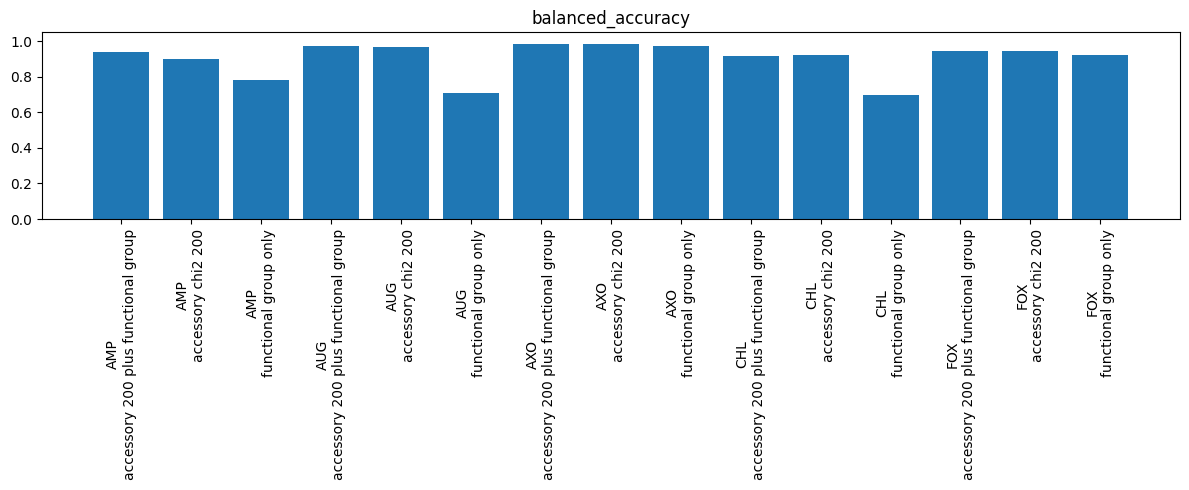

Saved: /content/salmonella_direction_H_domain/outputs/direction_H_balanced_accuracy_mean.png


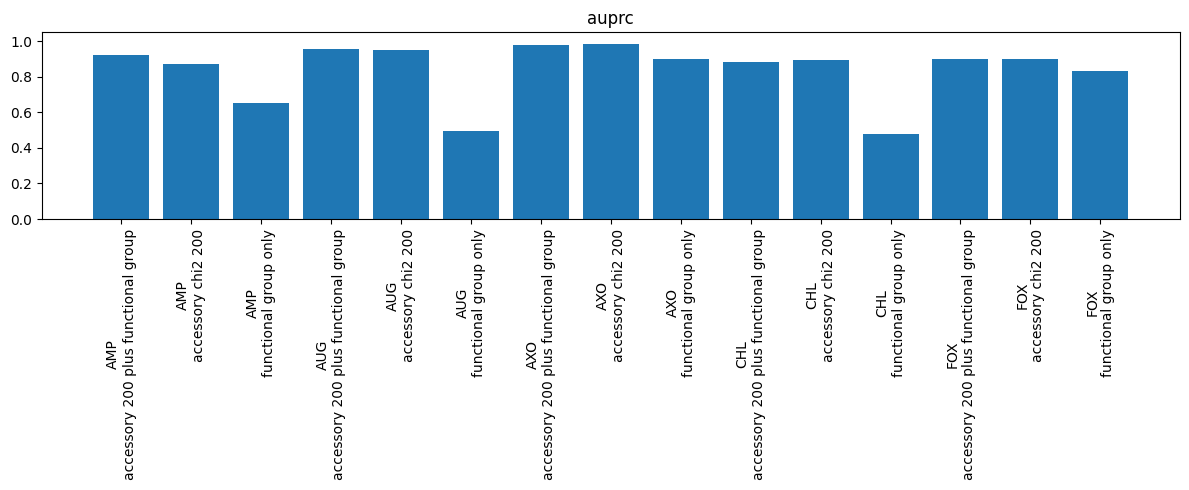

Saved: /content/salmonella_direction_H_domain/outputs/direction_H_auprc_mean.png


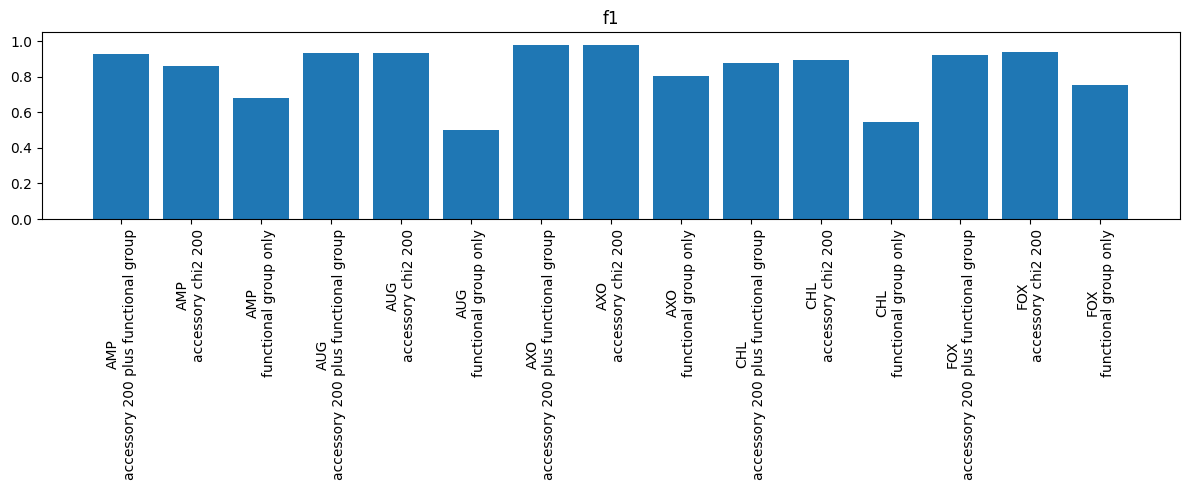

Saved: /content/salmonella_direction_H_domain/outputs/direction_H_f1_mean.png


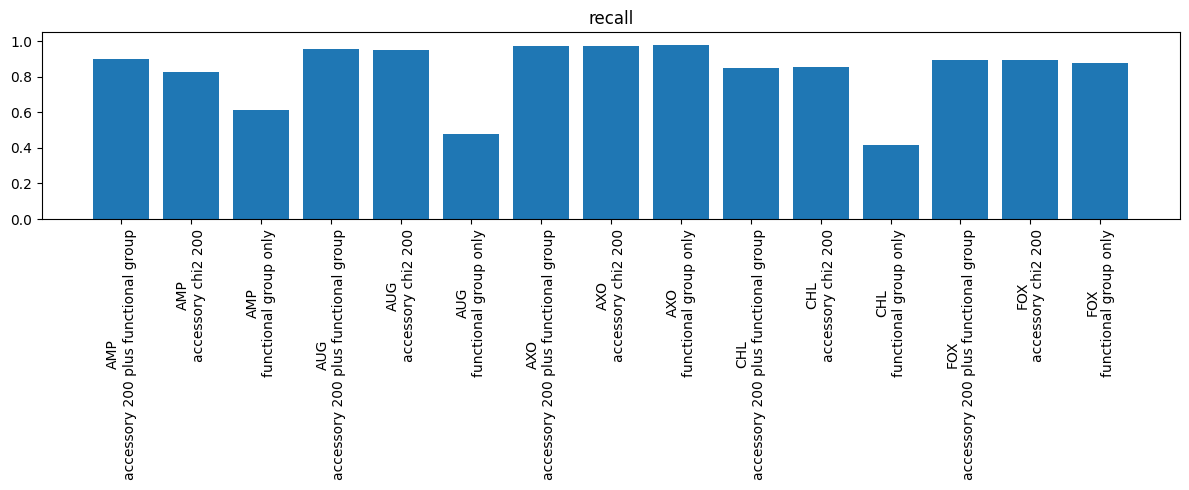

Saved: /content/salmonella_direction_H_domain/outputs/direction_H_recall_mean.png


In [11]:
# =========================
# 10. Plot results
# =========================
import matplotlib.pyplot as plt

plot_df = summary_H.copy()
plot_df['setting'] = plot_df['representation'] + ' | ' + plot_df['model']

for metric in ['balanced_accuracy_mean', 'auprc_mean', 'f1_mean', 'recall_mean']:
    plt.figure(figsize=(12, 5))
    # lấy best model theo representation để biểu đồ gọn hơn
    tmp = plot_df.sort_values(['drug','representation',metric], ascending=[True, True, False]).groupby(['drug','representation']).head(1)
    labels = []
    values = []
    for _, r in tmp.iterrows():
        labels.append(f"{r['drug']}\n{r['representation'].replace('_',' ')}")
        values.append(r[metric])
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=90)
    plt.ylim(0, 1.05)
    plt.title(metric.replace('_mean',''))
    plt.tight_layout()
    out = OUT_DIR / f'direction_H_{metric}.png'
    plt.savefig(out, dpi=200)
    plt.show()
    print('Saved:', out)


In [12]:
# =========================
# 11. Stable selected features and annotation summary
# =========================
stable_rows = []
for drug, counter in selected_by_drug.items():
    total = len(RANDOM_SEEDS)
    for feat, count in counter.items():
        ann = get_annotation(feat)
        groups = classify_annotation(ann)
        stable_rows.append({
            'drug': drug,
            'feature': feat,
            'selected_count': count,
            'selected_frequency': count / total,
            'annotation': ann,
            'function_groups': ';'.join(groups) if groups else 'unannotated'
        })

stable_df = pd.DataFrame(stable_rows)
stable_df = stable_df.sort_values(['drug','selected_frequency','selected_count'], ascending=[True, False, False])
stable_df.to_csv(OUT_DIR / 'direction_H_stable_selected_features_annotated.csv', index=False)

print('Top stable features:')
display(stable_df.groupby('drug').head(20))

coverage = stable_df.groupby('drug').apply(lambda d: pd.Series({
    'n_selected_unique': len(d),
    'n_annotated': int((d['annotation'].astype(str).str.len() > 0).sum()),
    'annotation_coverage': float((d['annotation'].astype(str).str.len() > 0).mean())
})).reset_index()
display(coverage)
coverage.to_csv(OUT_DIR / 'direction_H_annotation_coverage.csv', index=False)


Top stable features:


,drug,feature,selected_count,selected_frequency,annotation,function_groups
0,AMP,group_3068,10,1.0,,unannotated
2,AMP,CJW30_15375,10,1.0,,unannotated
3,AMP,HF382_002470,10,1.0,,unannotated
5,AMP,GXH02_05140,10,1.0,Bacteriophage tail protein,phage_related
7,AMP,DSP25_11545,10,1.0,,unannotated
...,...,...,...,...,...,...
979,FOX,ET461_22950,10,1.0,,unannotated
980,FOX,CAR27_22395,10,1.0,,unannotated
981,FOX,CBH71_23260,10,1.0,,unannotated
982,FOX,HF382_004409,10,1.0,,unannotated


,drug,n_selected_unique,n_annotated,annotation_coverage
0,AMP,250.0,5.0,0.020000
1,AUG,238.0,5.0,0.021008
2,AXO,213.0,5.0,0.023474
3,CHL,263.0,5.0,0.019011
4,FOX,213.0,4.0,0.018779


In [13]:
# =========================
# 12. Optional HMMER-ready section
# =========================
print('HMMER version:')
!hmmscan -h | head -5

# Tìm protein FASTA trong repo. Nếu không có, notebook sẽ bỏ qua phần HMMER thật.
protein_files = []
for suf in ['.faa', '.faa.gz', '.fa', '.fasta', '.fasta.gz']:
    protein_files.extend(list(REPO_DIR.rglob(f'*{suf}')))

print('Số file protein/fasta tìm thấy:', len(protein_files))
for p in protein_files[:10]:
    print(' -', p)

HMM_DB_PATH = Path('/content/your_hmm_database.hmm')  # nếu có Pfam/Resfams thì đặt vào đây

if protein_files and HMM_DB_PATH.exists():
    print('Có protein FASTA và HMM DB. Có thể chạy hmmscan.')
    fasta = protein_files[0]
    out_domtbl = OUT_DIR / 'hmmer_scan.domtblout'
    cmd = f'hmmscan --domtblout {out_domtbl} {HMM_DB_PATH} {fasta}'
    print(cmd)
    !{cmd}
else:
    print('\nBỎ QUA HMMER thật sự.')
    print('Lý do: cần đồng thời protein FASTA và HMM database như Pfam/Resfams.')
    print('Dataset hiện tại chủ yếu cung cấp ma trận gen/đặc trưng đã xử lý, không bảo đảm có protein FASTA đầy đủ.')
    print('Notebook đã thực hiện bản thay thế nhẹ hơn: annotation/domain-like feature augmentation từ bảng Roary/manual annotation.')


HMMER version:
# hmmscan :: search sequence(s) against a profile database
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Số file protein/fasta tìm thấy: 0

BỎ QUA HMMER thật sự.
Lý do: cần đồng thời protein FASTA và HMM database như Pfam/Resfams.
Dataset hiện tại chủ yếu cung cấp ma trận gen/đặc trưng đã xử lý, không bảo đảm có protein FASTA đầy đủ.
Notebook đã thực hiện bản thay thế nhẹ hơn: annotation/domain-like feature augmentation từ bảng Roary/manual annotation.


In [ ]:
# =========================
# 13. Conclusion
# =========================
lines = []
lines.append('# Direction H — Kết luận tự động')
lines.append('')
lines.append('Mục tiêu Direction H là kiểm tra xem đặc trưng nhóm chức năng/domain-like có giúp tăng hiệu năng hoặc tăng khả năng giải thích so với gen phụ chọn bằng chi-square hay không.')
lines.append('')
lines.append('## Thiết lập tốt nhất theo từng thuốc')
for _, r in best_H.iterrows():
    lines.append(f"- {r['drug']}: tốt nhất là {r['representation']} + {r['model']}, balanced accuracy = {r['balanced_accuracy_mean']:.3f} ± {r['balanced_accuracy_std']:.3f}, AUPRC = {r['auprc_mean']:.3f} ± {r['auprc_std']:.3f}.")
lines.append('')
# Kiểm tra functional group có thắng không
wins = best_H['representation'].str.contains('functional', case=False, regex=False).sum()
combo_wins = best_H['representation'].str.contains('plus_functional', case=False, regex=False).sum()
lines.append(f'- Số thuốc mà thiết lập có functional/domain-like feature là tốt nhất: {wins}/5.')
lines.append(f'- Số thuốc mà accessory + functional/domain-like feature là tốt nhất: {combo_wins}/5.')
lines.append('')
lines.append('Diễn giải: nếu functional/domain-like feature thắng ít, nghĩa là nhóm chức năng hiện tại chưa đủ giàu để tăng hiệu năng, nhưng vẫn hữu ích để giải thích. Nếu accessory + functional thắng ở một số thuốc, có thể xem đây là hướng feature augmentation cần tối ưu thêm.')
lines.append('')
lines.append('## Ghi chú về HMMER')
lines.append('HMMER thật sự cần protein FASTA và HMM database. Nếu repo không có protein FASTA hoặc chưa có Pfam/Resfams database, notebook bỏ qua hmmscan và dùng hướng thay thế là feature nhóm chức năng dựa trên annotation.')

conclusion_text = '\n'.join(lines)
print(conclusion_text)
with open(OUT_DIR / 'AUTO_CONCLUSION_DIRECTION_H.md', 'w') as f:
    f.write(conclusion_text)


# Direction H — Kết luận tự động

Mục tiêu Direction H là kiểm tra xem đặc trưng nhóm chức năng/domain-like có giúp tăng hiệu năng hoặc tăng khả năng giải thích so với gen phụ chọn bằng chi-square hay không.

## Thiết lập tốt nhất theo từng thuốc
- AMP: tốt nhất là accessory_200_plus_functional_group + LR_plain, balanced accuracy = 0.941 ± 0.019, AUPRC = 0.920 ± 0.026.
- AUG: tốt nhất là accessory_200_plus_functional_group + LR_balanced, balanced accuracy = 0.971 ± 0.013, AUPRC = 0.956 ± 0.022.
- AXO: tốt nhất là accessory_200_plus_functional_group + LR_balanced, balanced accuracy = 0.985 ± 0.019, AUPRC = 0.979 ± 0.028.
- CHL: tốt nhất là accessory_chi2_200 + LR_balanced, balanced accuracy = 0.921 ± 0.045, AUPRC = 0.885 ± 0.075.
- FOX: tốt nhất là accessory_chi2_200 + LR_plain, balanced accuracy = 0.946 ± 0.031, AUPRC = 0.899 ± 0.057.

- Số thuốc mà thiết lập có functional/domain-like feature là tốt nhất: 3/5.
- Số thuốc mà accessory + functional/domain-like feature là tốt nhất: 3/5.



In [ ]:
# =========================
# 14. Zip 
# =========================
zip_path = BASE_DIR / 'salmonella_direction_H_outputs.zip'
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace('.zip',''), 'zip', OUT_DIR)
print('Đã nén kết quả:', zip_path)
print('Tải bằng:')
print(f"from google.colab import files\nfiles.download('{zip_path}')")


Đã nén kết quả: /content/salmonella_direction_H_domain/salmonella_direction_H_outputs.zip
Tải bằng:
from google.colab import files
files.download('/content/salmonella_direction_H_domain/salmonella_direction_H_outputs.zip')
